In [41]:
import os

if os.getcwd().split("/")[-1] != "neurolib":
    os.chdir('..')

os.chdir('..')
datadir = os.path.join(os.getcwd(), "neurolib", "whole-brain")

print(datadir)

/mnt/antares_raid/home/salfenmoser/neurolib/whole-brain


In [42]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io
from numba.typed import Dict
from numba.core import types
import pickle

from neurolib.models.wc import WCModel
from neurolib.utils.stimulus import ZeroInput
from neurolib.control.optimal_control import oc_wc, cost_functions

import matplotlib as mpl
label_size= 20
mpl.rcParams['xtick.labelsize'] = label_size
mpl.rcParams['ytick.labelsize'] = label_size
mpl.rcParams['font.size'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['figure.titlesize'] = label_size
mpl.rcParams['lines.linewidth'] = 1


# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2

weights = Dict.empty(
        key_type=types.unicode_type,
        value_type=types.float64,
    )

weights["w_2"] = 0.0
weights["w_1"] = 0.0
weights["w_1T"] = 0.0
weights["w_1D"] = 1.0

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
N = 100

folders = ["NAP_002", "NAP_003", "NAP_005", "NAP_007", "NAP_009", "NAP_010", "NAP_011", "NAP_012", "NAP_013", "NAP_014", "NAP_015", "NAP_016", "NAP_018", "NAP_020", "NAP_022", "NAP_024", "NAP_025", "NAP_026", "NAP_027", "NAP_028", "NAP_029", "NAP_031", "NAP_032", "NAP_033", "NAP_035", "NAP_036"]
cmat_sum = np.zeros((N,N))
dmat_sum = np.zeros((N,N))

for f in folders:
    path = os.path.join(os.getcwd(), "data", "structural_data", "Sch100", f, "SC", "DTI_CM.mat")
    cmat_sum += scipy.io.loadmat(path)["SC"]
    path = os.path.join(os.getcwd(), "data", "structural_data", "Sch100", f, "SC", "DTI_LEN.mat")
    dmat_sum += scipy.io.loadmat(path)["LEN"]

cmat_av = cmat_sum/len(folders)
dmat_av = dmat_sum/len(folders)

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/antares_raid/home/salfenmoser/data/structural_data/Sch100/NAP_002/SC/DTI_CM.mat'

In [22]:
coords = [[1.6, 0.0], [1.7, 0.1]] #1st: multistable     // 2nd: unistable synchronized

data_0_L1, data_1_L1, data_2_L1 = dict(), dict(), dict()
data_0_L1["coordinates"] = coords[0]
data_1_L1["coordinates"] = coords[0]
data_2_L1["coordinates"] = coords[1]
lng = int(4*1e3)

for d in [data_0_L1, data_1_L1, data_2_L1]:
    d["weights"] = np.zeros((100))
    d["control"] = [None] * len(data_0_L1["weights"])
    d["state"] = [None] * len(data_0_L1["weights"])
    d["init_state"] = None
    d["energy_input"] = np.zeros((len(d["weights"])))
    d["sync_cost"] = np.zeros((len(d["weights"])))
    d["state_uncontrolled"] = np.zeros((N,2,lng))

data_1_L1["weights"] *= -1

In [5]:
def setparams(model):
    model.params.c_excinh = 12  # local E-I coupling
    model.params.signalV = 80.0
    model.params.K_gl = 0.5  # global coupling strength
    model.params.a_exc = 1.  # excitatory gain
    model.params.a_inh = 1.  # inhibitory gain
    model.params.mu_exc = 5.0  # excitatory firing threshold
    model.params.mu_inh = 5.0  # inhibitory firing threshold

def plot_control(c, s, dur, dt, fat=[], filename=None, title=None):
    fig, ax = plt.subplots(2,1, figsize=(32,8), sharex=True)
    time_array = np.arange(0, dur+dt, dt)

    cmax = np.amax(np.abs(c))
    y1lim = [-cmax* 1.1, cmax* 1.1]

    for n in range(N):
        if n in fat:
            ax[0].plot(time_array, s[n,0,:], linewidth=4)
        else:
            ax[0].plot(time_array, s[n,0,:])
        ax[1].plot(time_array, c[n,0,:])

    ax[0].set_xlim(0, dur)

    ax[1].set_ylim(y1lim)

    ax[1].set_xlabel("Time")
    ax[0].set_ylabel("Activity")
    ax[1].set_ylabel("Control")

    plt.subplots_adjust(
                    wspace=0.15,
                    hspace=0.1)
    
    fig.align_ylabels([ax[0]])
    
    if title is not None:
        fig.suptitle(title)

    if filename is not None:
        plt.savefig(filename, bbox_inches='tight', dpi=200)

    plt.show()
    return

def get_results(d, wi, mc):
    d["control"][wi] = mc.control.copy()
    d["state"][wi] = mc.get_xs()
    d["energy_input"][wi] = cost_functions.control_strength_cost(mc.control, weights, dt)
    d["sync_cost"][wi] = (mc.compute_total_cost() - d["energy_input"][wi])/d["weights"][wi]

def dump_data():
    with open(os.path.join(datadir, 'wb_L1_cc_all_2.pickle'), 'wb') as f:
        pickle.dump(data_0_L1, f)

controlmat = np.zeros((N,2))
controlmat[:,0] = 1

costmat = np.zeros((N, 2))
costmat[:,0] = 1.

duration = 400.
target_period = 1

int0 = 0
int1 = None

max_cntrl = 5
pr = np.arange(0,101,1)
dt = 0.1

------------------- seed =  1


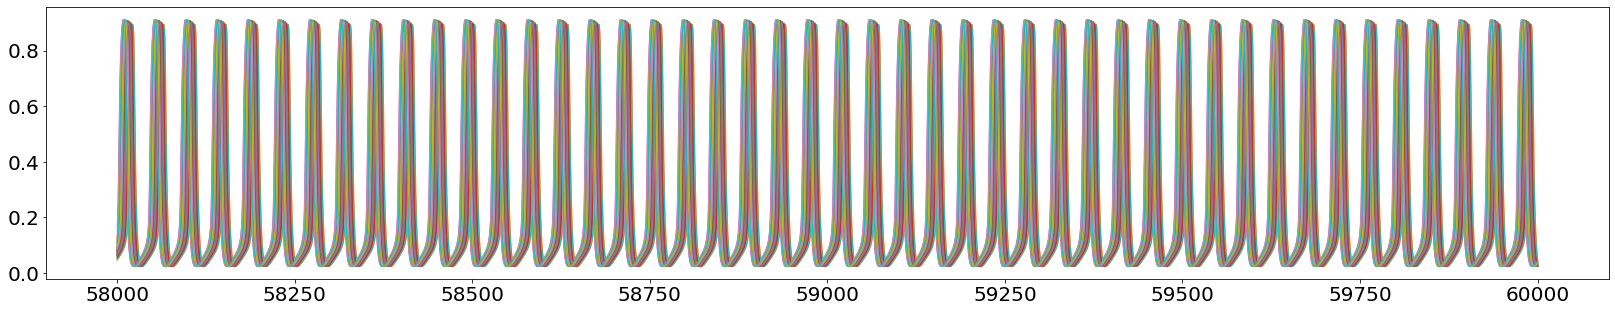

0.032164549250778954
-0.6242257109598518
------------------- seed =  25


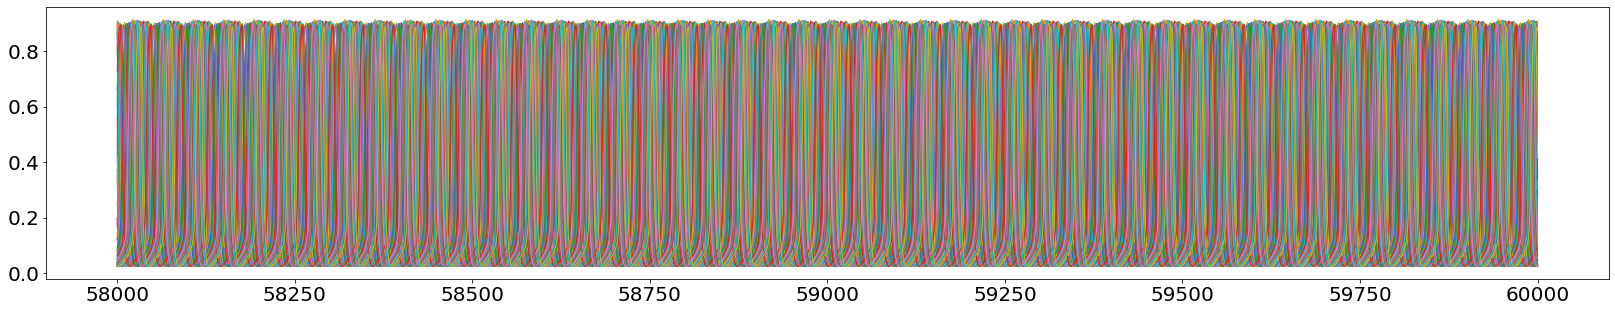

0.08426829728692982
-0.025985539150927384


In [23]:
point = 0
seed = [1, 25]

#for s in np.arange(0,50,1):
for i_s, s in enumerate(seed):

    print("------------------- seed = ", s)

    model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=s)
    testd = 60.*1e3     # needs to stay 60!!!!!
    dt = model.params.dt
    model.params.duration = testd
    model.params.seed = s
    setparams(model)

    #zero_input = ZeroInput().generate_input(duration=testd+model.params.dt, dt=model.params.dt)
    #input = zero_input.copy()
    #input[0,int(0.*1e3/dt):int(5.*1e3/dt)] = 1.

    #print(model.params.exc_init[0,0])

    model.params.exc_ext_baseline = data_0_L1["coordinates"][0]
    model.params.exc_inh_baseline = data_0_L1["coordinates"][1]

    #model.params.exc_ext = input
    model.run()

    plt.figure(figsize=(28,5))

    for n in range(N):
        plt.plot(model.t[-int(2.*1e3/dt):], model.exc[n,-int(2.*1e3/dt):], linewidth=1)
    plt.show()

    nmaxdelay = model.getMaxDelay()
    einit = np.zeros((N, nmaxdelay+1))
    iinit = np.zeros((N, nmaxdelay+1))

    state = np.zeros((N,2,lng))

    for n in range(N):
        einit[n,:] = model.exc[n,-nmaxdelay-1:]
        iinit[n,:] = model.inh[n,-nmaxdelay-1:]
        state[n,0,:] = model.exc[n, -lng:]

    if i_s == 0:
        data_0_L1["init_state"] = [einit, iinit]
        data_0_L1["state_uncontrolled"] = state.copy()
    else:
        data_1_L1["init_state"] = [einit, iinit]
        data_1_L1["state_uncontrolled"] = state.copy()

    var_cost_asyn = np.sum(cost_functions.var_cost(state, costmat, [0,lng], dt)[0,:])*dt
    print(var_cost_asyn)

    cc_cost = np.sum(cost_functions.cc_cost(state, costmat, [0,lng], dt)[0,:])*dt
    print(cc_cost)

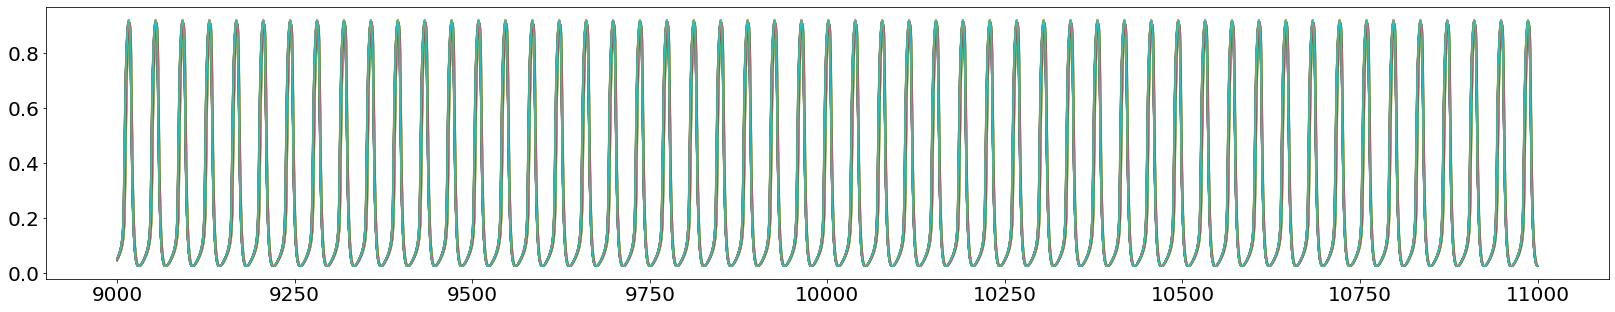

0.002332105821483664
-0.9775374609292389


In [24]:
model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=0)
testd = 11.*1e3   ## needs to stay 11
dt = model.params.dt
model.params.duration = testd
setparams(model)

model.params.exc_ext_baseline = data_2_L1["coordinates"][0]
model.params.exc_inh_baseline = data_2_L1["coordinates"][1]

#model.params.exc_ext = input
model.run()

plt.figure(figsize=(28,5))

for n in range(N):
    plt.plot(model.t[-int(2.*1e3/dt):], model.exc[n,-int(2.*1e3/dt):], linewidth=1)
plt.show()

nmaxdelay = model.getMaxDelay()
einit = np.zeros((N, nmaxdelay+1))
iinit = np.zeros((N, nmaxdelay+1))

state = np.zeros((N,2,lng))

for n in range(N):
    einit[n,:] = model.exc[n,-nmaxdelay-1:]
    iinit[n,:] = model.inh[n,-nmaxdelay-1:]
    state[n,0,:] = model.exc[n, -lng:]

data_2_L1["init_state"] = [einit, iinit]
data_2_L1["state_uncontrolled"] = state.copy()

var_cost_asyn = np.sum(cost_functions.var_cost(state, costmat, [0,lng], dt)[0,:])*dt
print(var_cost_asyn)

cc_cost = np.sum(cost_functions.cc_cost(state, costmat, [0,lng], dt)[0,:])*dt
print(cc_cost)

In [6]:
with open(os.path.join(datadir, 'wb_L1_cc_all_2.pickle'), 'rb') as f:
    data_read = pickle.load(f)

data_2_L1 = data_read

In [26]:
print(data_2_L1["weights"])

[ -10.  -12.  -14.  -16.  -18.  -20.  -22.  -24.  -26.  -28.  -30.  -32.
  -34.  -36.  -38.  -40.  -42.  -44.  -46.  -48.  -50.  -52.  -54.  -56.
  -58.  -60.  -62.  -64.  -66.  -68.  -70.  -72.  -74.  -76.  -78.  -80.
  -82.  -84.  -86.  -88.  -90.  -92.  -94.  -96.  -98. -100. -102. -104.
 -106. -108. -110. -112. -114. -116. -118. -120. -122. -124. -126. -128.
 -130. -132. -134. -136. -138. -140. -142. -144. -146. -148. -150. -152.
 -154. -156. -158. -160. -162. -164. -166. -168. -170. -172. -174. -176.
 -178. -180. -182. -184. -186. -188. -190. -192. -194. -196. -198. -200.
 -202. -204. -206. -208.]


In [25]:
data_2_L1["weights"][0] = -10.
for n in range(N-1):
    data_2_L1["weights"][n+1] = data_2_L1["weights"][n] - 2.

In [11]:
def optimize_model(model, step_exp_array, wi, it):
    for k in step_exp_array:
        model.zero_step_encountered = False
        model.step = 10.**(k)
        model.optimize(it)

        get_results(d, wi, model)
        dump_data()

------------------------------------------------------------ wi =  0 -10.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 9.689215621130035
Final cost : 9.689215621130035
Compute control for a deterministic system
Cost in iteration 0: 9.689215621130035
Cost in iteration 1: 9.689215621130035
Converged in iteration 1 with cost 9.689215621130035
Final cost : 9.689215621130035
Compute control for a deterministic system
Cost in iteration 0: 9.689215621130035
Cost in iteration 1: 9.689215621130035
Converged in iteration 1 with cost 9.689215621130035
Final cost : 9.689215621130035
Compute control for a deterministic system
Cost in iteration 0: 9.689215621130035
Cost in iteration 1: 9.689215621130035
Converged in iteration 1 with cost 9.689215621130035
Final cost : 9.689215621130035
Compute control for a deterministic system
Cost in iteration 0: 9.689215621130035
Cost in iteration 1: 9.689215621130035
Converged in iteration 1 with

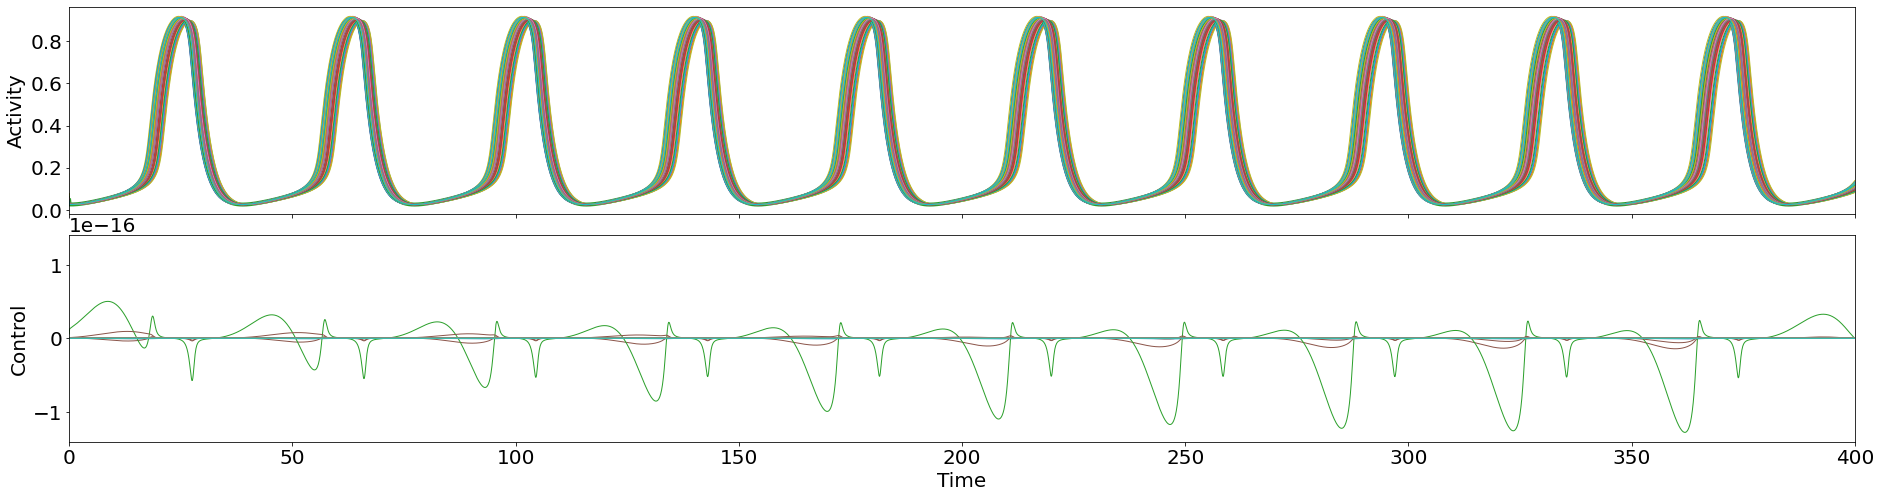

------------------------------------------------------------ wi =  5 -20.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 18.738042023985347
Final cost : 18.738042023985347
Compute control for a deterministic system
Cost in iteration 0: 18.738042023985347
Cost in iteration 1: 18.738042023985347
Cost in iteration 2: 18.738042023985347
Converged in iteration 2 with cost 18.738042023985347
Final cost : 18.738042023985347
Compute control for a deterministic system
Cost in iteration 0: 18.738042023985347
Cost in iteration 1: 18.738042023985347
Converged in iteration 1 with cost 18.738042023985347
Final cost : 18.738042023985347
Compute control for a deterministic system
Cost in iteration 0: 18.738042023985347
Cost in iteration 1: 18.738042023985347
Cost in iteration 2: 18.738042023985347
Converged in iteration 2 with cost 18.738042023985347
Final cost : 18.738042023985347
Compute control for a deterministic system
Cost in itera

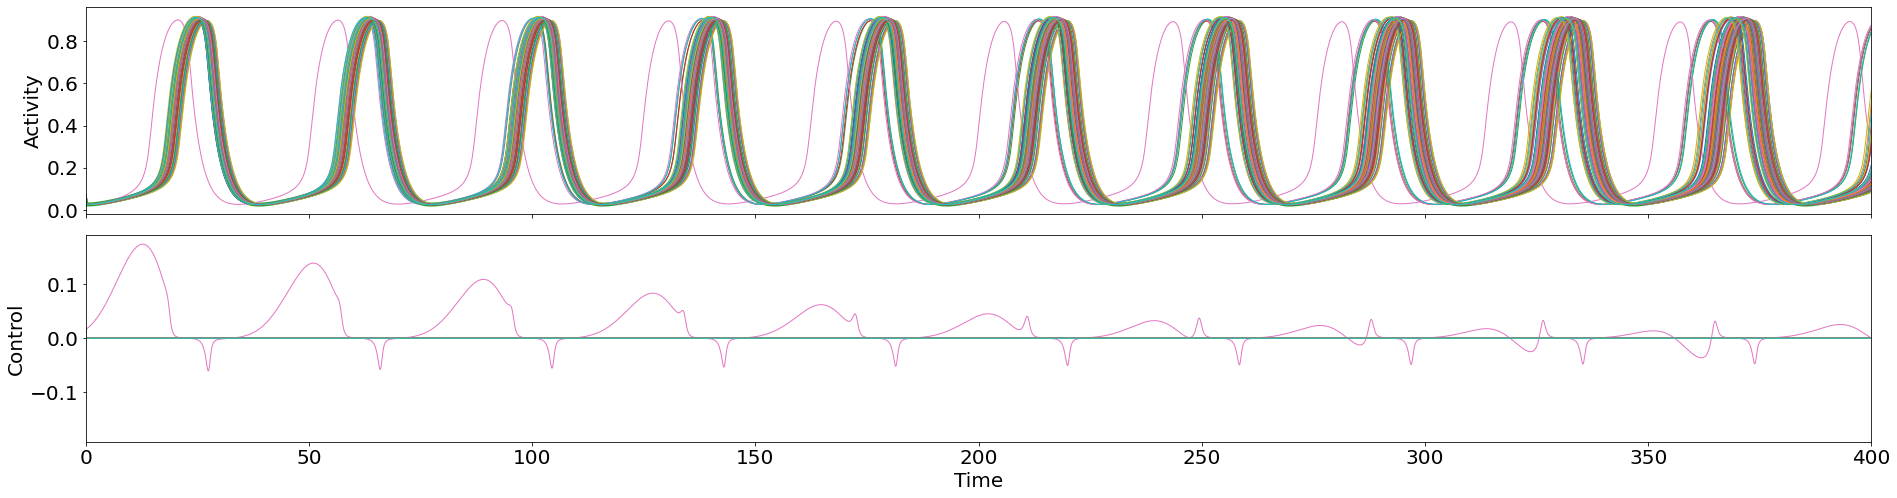

------------------------------------------------------------ wi =  10 -30.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 29.067646863390088
Final cost : 29.067646863390088
Compute control for a deterministic system
Cost in iteration 0: 29.067646863390088
Cost in iteration 1: 29.067646863390088
Cost in iteration 2: 29.067646863390088
Converged in iteration 2 with cost 29.067646863390088
Final cost : 29.067646863390088
Compute control for a deterministic system
Cost in iteration 0: 29.067646863390088
Cost in iteration 1: 29.067646863390088
Converged in iteration 1 with cost 29.067646863390088
Final cost : 29.067646863390088
Compute control for a deterministic system
Cost in iteration 0: 29.067646863390088
Cost in iteration 1: 29.067646863390088
Cost in iteration 2: 29.067646863390088
Converged in iteration 2 with cost 29.067646863390088
Final cost : 29.067646863390088
Compute control for a deterministic system
Cost in iter

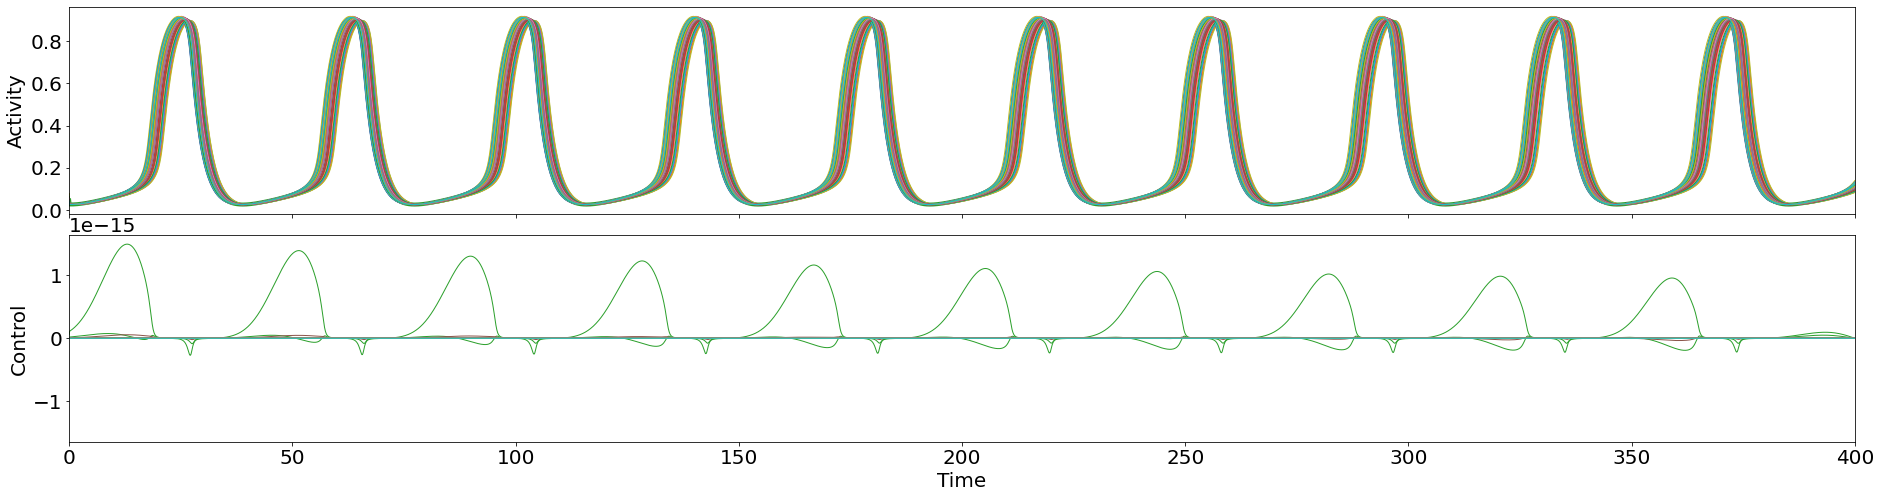

------------------------------------------------------------ wi =  15 -40.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 30.758374813223693
Final cost : 30.758374813223693
Compute control for a deterministic system
Cost in iteration 0: 30.758374813223693
Cost in iteration 1: 30.75837241182029
Cost in iteration 2: 30.75836760903155
Cost in iteration 3: 30.758358003528446
Cost in iteration 4: 30.75833879281968
Final cost : 30.75833879281968
Compute control for a deterministic system
Cost in iteration 0: 30.75833879281968
Cost in iteration 1: 30.75833879281968
Cost in iteration 2: 30.75833879281968
Converged in iteration 2 with cost 30.75833879281968
Final cost : 30.75833879281968
Compute control for a deterministic system
Cost in iteration 0: 30.75833879281968
Cost in iteration 1: 30.75833879281968
Cost in iteration 2: 30.75833879281968
Converged in iteration 2 with cost 30.75833879281968
Final cost : 30.75833879281968
Com

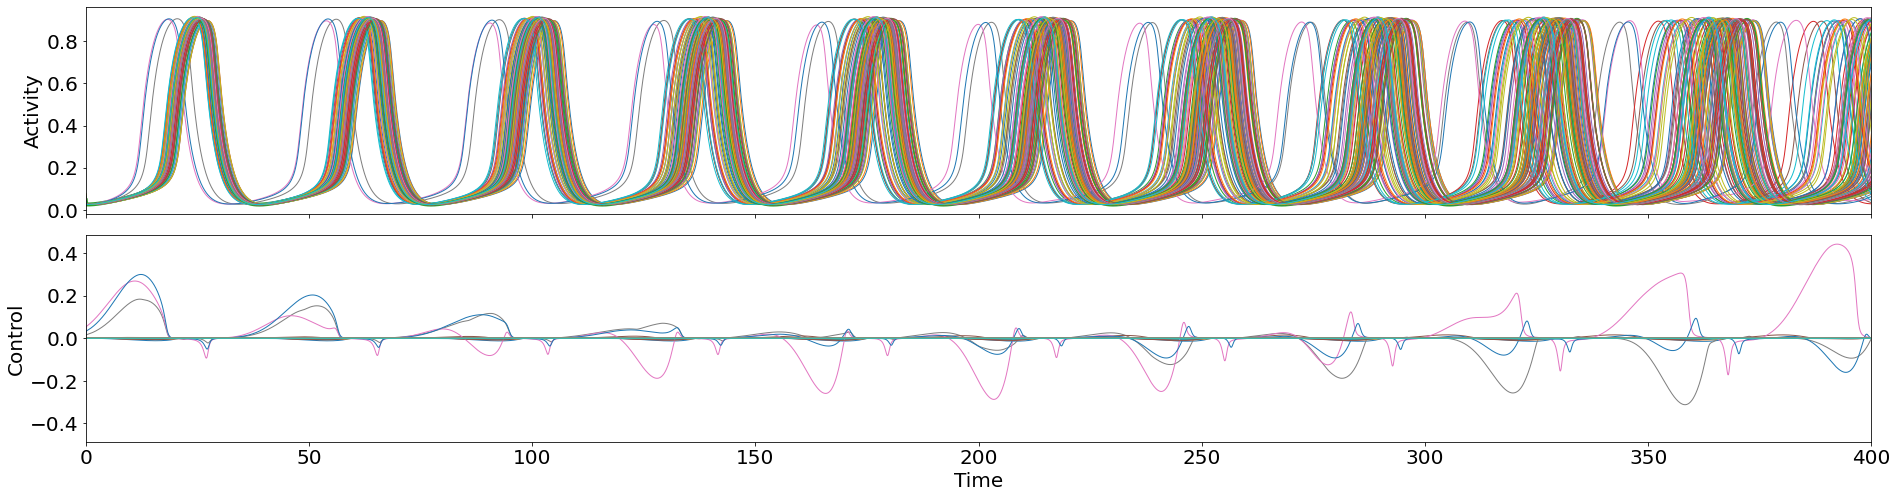

------------------------------------------------------------ wi =  20 -50.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 31.84085532661761
Final cost : 31.84085532661761
Compute control for a deterministic system
Cost in iteration 0: 31.84085532661761
Cost in iteration 1: 31.840852846414865
Cost in iteration 2: 31.840847886003
Cost in iteration 3: 31.840837965155906
Cost in iteration 4: 31.840818123372877
Final cost : 31.840818123372877
Compute control for a deterministic system
Cost in iteration 0: 31.840818123372877
Cost in iteration 1: 31.629097937563618
Cost in iteration 2: 31.629088408824913
Cost in iteration 3: 31.628773216259894
Cost in iteration 4: 31.628088864077537
Final cost : 31.628088864077537
Compute control for a deterministic system
Cost in iteration 0: 31.628088864077537
Cost in iteration 1: 31.628088864077537
Cost in iteration 2: 31.628088864077537
Converged in iteration 2 with cost 31.628088864077537
F

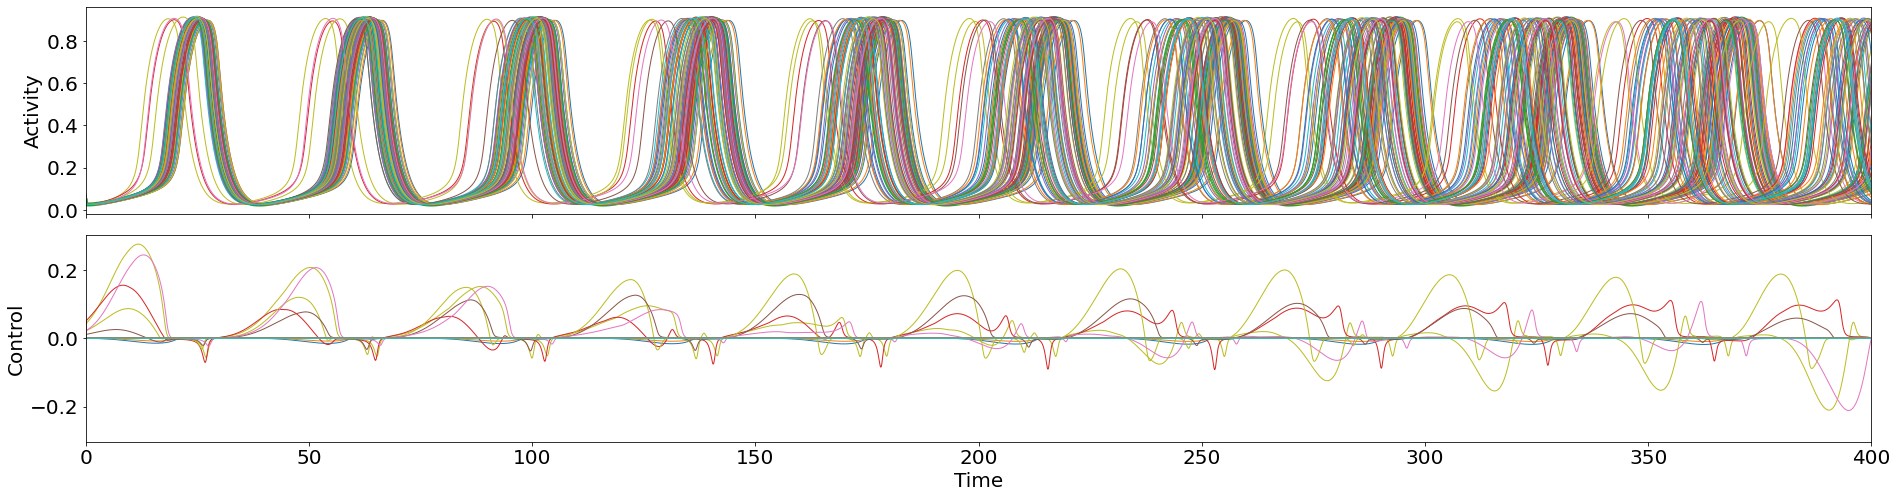

------------------------------------------------------------ wi =  25 -60.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 44.21592967714988
Final cost : 44.21592967714988
Compute control for a deterministic system
Cost in iteration 0: 44.21592967714988
Cost in iteration 1: 44.2159278365522
Cost in iteration 2: 44.21592415537593
Cost in iteration 3: 44.21591679309874
Cost in iteration 4: 44.215902068848486
Final cost : 44.215902068848486
Compute control for a deterministic system
Cost in iteration 0: 44.215902068848486
Cost in iteration 1: 44.215902068848486
Cost in iteration 2: 44.215902068848486
Converged in iteration 2 with cost 44.215902068848486
Final cost : 44.215902068848486
Compute control for a deterministic system
Cost in iteration 0: 44.215902068848486
Cost in iteration 1: 44.215902068848486
Cost in iteration 2: 44.215902068848486
Converged in iteration 2 with cost 44.215902068848486
Final cost : 44.215902068848

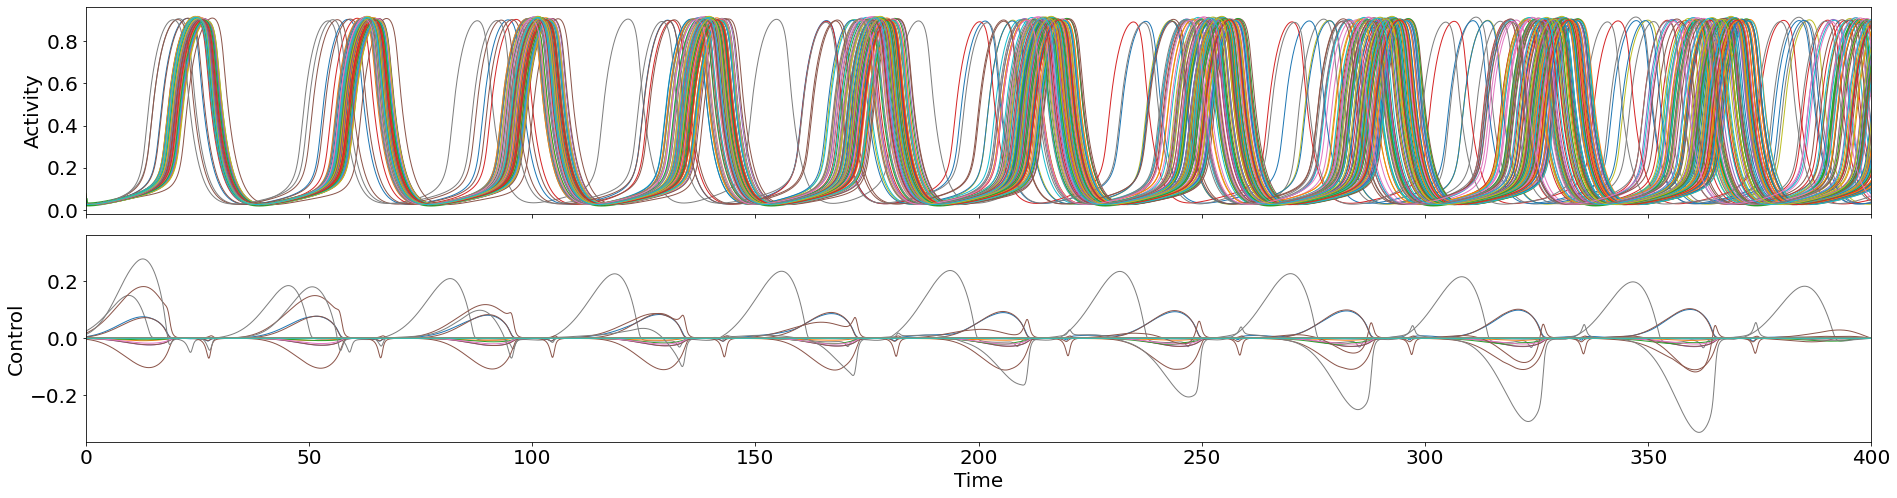

------------------------------------------------------------ wi =  30 -70.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 56.01348358363639
Final cost : 56.01348358363639
Compute control for a deterministic system
Cost in iteration 0: 56.01348358363639
Cost in iteration 1: 56.01348205256858
Cost in iteration 2: 56.01347899045933
Cost in iteration 3: 56.01347286635453
Cost in iteration 4: 56.01346061866069
Final cost : 56.01346061866069
Compute control for a deterministic system
Cost in iteration 0: 56.01346061866069
Cost in iteration 1: 56.01346060395087
Cost in iteration 2: 56.01346055894856
Cost in iteration 3: 56.01346046771096
Cost in iteration 4: 56.01346028523543
Final cost : 56.01346028523543
Compute control for a deterministic system
Cost in iteration 0: 56.01346028523543
Cost in iteration 1: 56.01346028523543
Converged in iteration 1 with cost 56.01346028523543
Final cost : 56.01346028523543
Compute control for a

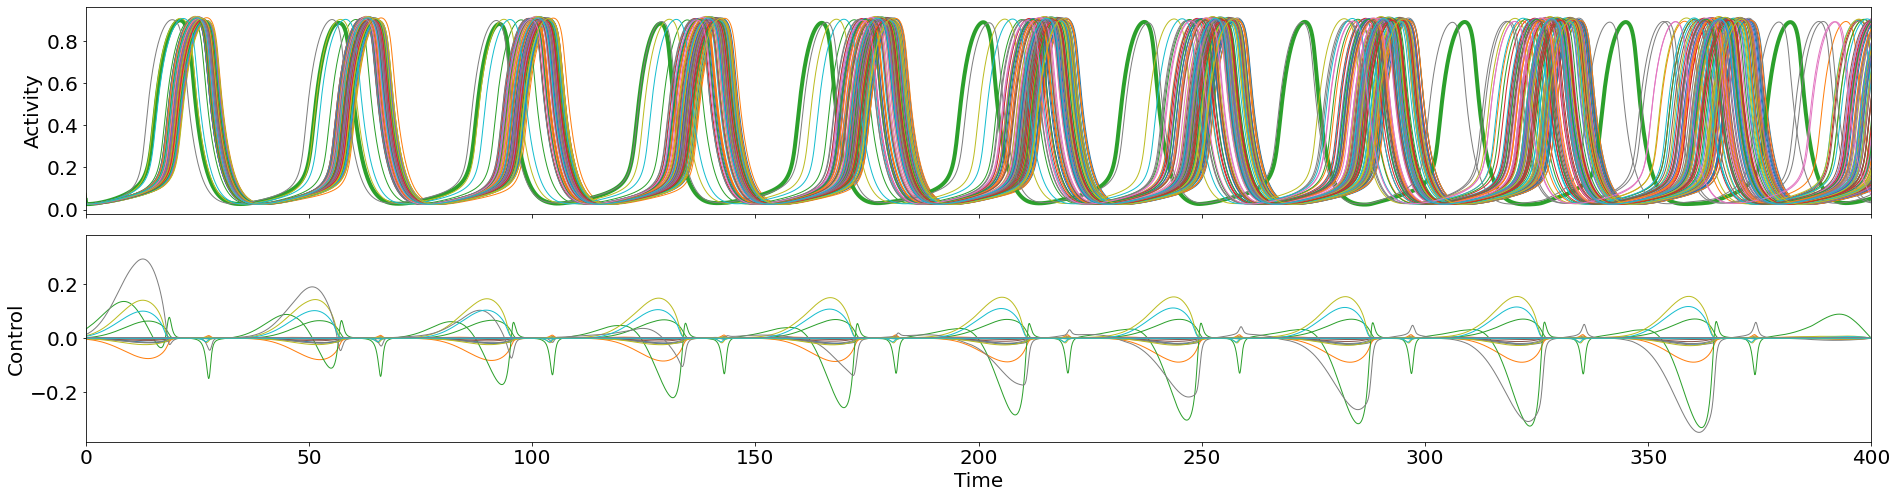

------------------------------------------------------------ wi =  35 -80.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 60.68473698450074
Final cost : 60.68473698450074
Compute control for a deterministic system
Cost in iteration 0: 60.68473698450074
Cost in iteration 1: 60.684734136766515
Cost in iteration 2: 60.68472844136285
Cost in iteration 3: 60.684717050820325
Cost in iteration 4: 60.68469427083047
Final cost : 60.68469427083047
Compute control for a deterministic system
Cost in iteration 0: 60.68469427083047
Cost in iteration 1: 57.99462574608866
Cost in iteration 2: 57.99462574204106
Cost in iteration 3: 57.99462572728174
Cost in iteration 4: 57.99462570894744
Final cost : 57.99462570894744
Compute control for a deterministic system
Cost in iteration 0: 57.99462570894744
Cost in iteration 1: 57.99462570894744
Cost in iteration 2: 57.99462570894744
Converged in iteration 2 with cost 57.99462570894744
Final cost 

In [ ]:
it = 4
d = data_2_L1

for wi in np.arange(0,100,5):
    print("------------------------------------------------------------ wi = ", wi, d["weights"][wi])

    model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=0)
    model.params.exc_init = d["init_state"][0]
    model.params.inh_init = d["init_state"][1]
    setparams(model)

    model.params["exc_ext_baseline"] =  d["coordinates"][0]
    model.params["inh_ext_baseline"] =  d["coordinates"][1]
    model.params.duration = duration

    model.run()

    model_controlled = oc_wc.OcWc(model, target_period, print_array=pr, cost_interval=(int0, int1), control_interval=(int0, int1), cost_matrix=costmat, control_matrix=controlmat)
    model_controlled.weights["w_p"] = 0.
    model_controlled.weights["w_1D"] = 1.
    model_controlled.weights["w_cc"] = d["weights"][wi]
    model_controlled.maximum_control_strength = max_cntrl
    
    if type(d["control"][wi]) != type(None):
        model_controlled.control = d["control"][wi].copy()
        model_controlled.update_input()

    model_controlled.channelwise_optimization = True
    model_controlled.optimize(0)

    for j in range(1):
        model_controlled.grad_method = 0
        optimize_model(model_controlled, [-6, 0, 6, -2], wi, it)
        model_controlled.grad_method = 1
        optimize_model(model_controlled, [-6, 0, 6, -2], wi, it)
    
    maxnodeind = np.argmax(np.sum(np.sum(d["control"][0]**2, axis=2), axis=1))
    print("max node ind = ", maxnodeind)
    plot_control(model_controlled.control, model_controlled.get_xs(), duration, dt, fat=[maxnodeind], filename=None, title=None)